In [ ]:
import os

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
import torch
import torch.optim as optim

from PIL import Image
import nibabel as nib
import numpy as np
from sklearn.metrics import confusion_matrix
import random
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Data
training_data_path = "../data/raw/brats_nii/training"
validation_data_path = "../data/raw/brats_nii/validation"
slices_per_mri = 155

T1CE_SUFFIX = "_t1ce.nii"
T2_SUFFIX = "_t2.nii"
FLAIR_SUFFIX = "_flair.nii"
SEG_SUFFIX = "_seg.nii"

RAND_SEED = 18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("NVIDIA Cuda available: ", torch.cuda.is_available())
print("GPU: ", torch.cuda.get_device_name(0))

In [35]:
def get_images_paths(data_path):
    images = []
    for patient_folder in os.listdir(data_path):
        patient_path = os.path.join(training_data_path, patient_folder)
        if not os.path.isdir(patient_path):
            continue
        images.append(patient_path)
    return images, masks

def normalize(image):
    # Z-score
    return (image - np.mean(image)) / (np.std(image) + 1e-8)

def get_patient_dirs(data_path):
    patient_dirs = []
    for patient_folder in os.listdir(data_path):
        patient_path = os.path.join(data_path, patient_folder)
        if os.path.isdir(patient_path):
            patient_dirs.append(patient_path)
    return patient_dirs

class BraTSDatasetTIF(Dataset):
    def __init__(self, data_path, data_size, slices_size, lazy_chunk_size=30):
        self.data_size = data_size
        self.slices_size = slices_size
        self.total_image_size = data_size*slices_size
        self.patient_dirs = get_patient_dirs(data_path)
        
        self.data = {}
        self.chunk_size = lazy_chunk_size
        self.chunk_start = 0
        self.chunk_end = lazy_chunk_size

        self._load_chunk()

    def __len__(self):
        return self.total_image_size

    def __getitem__(self, idx):
        if idx not in self.data:
            if idx >= self.total_image_size:
                raise ValueError(f"index {idx} not valid for length {self.total_image_size}")
            self._move_chunk(idx)
            self._load_chunk()
        return self.data[idx]

    def _move_chunk(self, idx):
        mri_from_slice = idx // self.slices_size
        self.chunk_start = mri_from_slice
        self.chunk_end = min(mri_from_slice + self.chunk_size, self.data_size)

    def _load_chunk(self):
        self.data.clear()
        for patient_idx in range(self.chunk_start, self.chunk_end):
            patient_dir = self.patient_dirs[patient_idx]
            basename = os.path.basename(patient_dir)

            t1ce = nib.load(os.path.join(patient_dir, basename + T1CE_SUFFIX)).get_fdata()
            t2   = nib.load(os.path.join(patient_dir, basename + T2_SUFFIX)).get_fdata()
            flair = nib.load(os.path.join(patient_dir, basename + FLAIR_SUFFIX)).get_fdata()
            seg  = nib.load(os.path.join(patient_dir, basename + SEG_SUFFIX)).get_fdata()
            
            if not (t1ce.shape == t2.shape == flair.shape == seg.shape):
                print("WARNING: data shape not consistent")
                continue

            t1ce = normalize(t1ce)
            t2 = normalize(t2)
            flair = normalize(flair)

            num_slices = t1ce.shape[2]
            start_slice_idx = patient_idx * self.slices_size
            for i in range(num_slices):
                image = np.stack([t1ce[:, :, i], t2[:, :, i], flair[:, :, i]], axis=0)  # (3, H, W) Combine into 3 channels
                mask = (seg[:, :, i] > 0).astype(np.float32)  # (H, W)

                self.data[start_slice_idx + i] = (
                    torch.tensor(image, dtype=torch.float32),
                    torch.tensor(mask[None, :, :], dtype=torch.float32)  # Add channel dim (1, H, W)
                )

class BraTSSliceDataset(Dataset):
    def __init__(self, data_path, slices_per_image):
        self.patient_dirs = get_patient_dirs(data_path)
        self.slice_index = []

        for patient_idx in range(len(self.patient_dirs)):
            for slice_idx in range(slices_per_image):
                self.slice_index.append((patient_idx, slice_idx))

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        patient_idx, slice_idx = self.slice_index[idx]
        patient_dir = self.patient_dirs[patient_idx]
        basename = os.path.basename(patient_dir)

        t1ce = nib.load(os.path.join(patient_dir, basename + T1CE_SUFFIX)).get_fdata()
        t2   = nib.load(os.path.join(patient_dir, basename + T2_SUFFIX)).get_fdata()
        flair = nib.load(os.path.join(patient_dir, basename + FLAIR_SUFFIX)).get_fdata()
        seg  = nib.load(os.path.join(patient_dir, basename + SEG_SUFFIX)).get_fdata()

        if not (t1ce.shape == t2.shape == flair.shape == seg.shape):
            raise ValueError("Inconsistent image shapes for patient:", basename)

        t1ce = normalize(t1ce)
        t2 = normalize(t2)
        flair = normalize(flair)

        image = np.stack([t1ce[:, :, slice_idx], t2[:, :, slice_idx], flair[:, :, slice_idx]], axis=0)  # (3, H, W)
        mask = (seg[:, :, slice_idx] > 0).astype(np.float32)  # (H, W)

        return (
            torch.tensor(image, dtype=torch.float32),
            torch.tensor(mask[None, :, :], dtype=torch.float32)  # (1, H, W)
        )

def visualize_random_batch(dataset, n=6, rand_seed=None, show_mask=True):
    if rand_seed is not None:
        random.seed(rand_seed)
        torch.manual_seed(rand_seed)

    indices = random.sample(range(len(dataset)), n)
    cols = 3
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 4, rows * 4))

    for i, idx in enumerate(indices):
        img, mask = dataset[idx]
        img_np = img * 0.5 + 0.5 # Undo Normalize
        img_np = img_np.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_np)
        if show_mask:
            plt.imshow(mask_np, cmap='Reds', alpha=0.4)  # Overlay mask
        plt.axis("off")
        plt.title(f"Sample {idx}")

    plt.tight_layout()
    plt.show()

In [36]:
def preprocess_brats_to_npy(data_path, output_path):
    os.makedirs(output_path, exist_ok=True)
    patient_dirs = get_patient_dirs(data_path)

    for patient_dir in tqdm(patient_dirs, desc="Preprocessing"):
        basename = os.path.basename(patient_dir)

        t1ce = nib.load(os.path.join(patient_dir, basename + T1CE_SUFFIX)).get_fdata()
        t2   = nib.load(os.path.join(patient_dir, basename + T2_SUFFIX)).get_fdata()
        flair = nib.load(os.path.join(patient_dir, basename + FLAIR_SUFFIX)).get_fdata()
        seg  = nib.load(os.path.join(patient_dir, basename + SEG_SUFFIX)).get_fdata()

        if not (t1ce.shape == t2.shape == flair.shape == seg.shape):
            print(f"Skipping inconsistent patient: {basename}")
            continue

        t1ce = normalize(t1ce)
        t2 = normalize(t2)
        flair = normalize(flair)

        num_slices = t1ce.shape[2]
        for i in range(num_slices):
            image = np.stack([t1ce[:, :, i], t2[:, :, i], flair[:, :, i]], axis=0)
            mask = (seg[:, :, i] > 0).astype(np.float32)

            np.save(os.path.join(output_path, f"{basename}_slice_{i:03d}_image.npy"), image)
            np.save(os.path.join(output_path, f"{basename}_slice_{i:03d}_mask.npy"), mask)

preprocess_brats_to_npy(training_data_path, "../data/preprocessed/brats_nii/")

Preprocessing:   1%|▎                                                                  | 2/369 [00:05<15:52,  2.59s/it]


KeyboardInterrupt: 

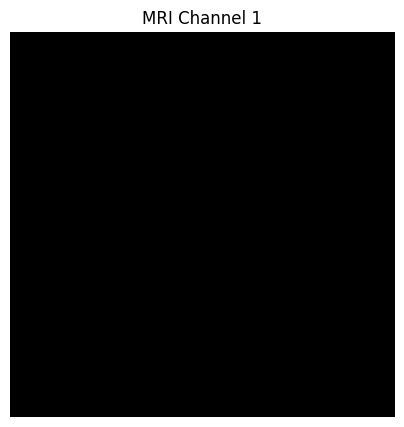

In [37]:
image = np.load("../data/preprocessed/brats_nii/BraTS20_Training_001_slice_000_image.npy")
mask = np.load("../data/preprocessed/brats_nii/BraTS20_Training_001_slice_000_mask.npy")

tens = (torch.tensor(image, dtype=torch.float32), torch.tensor(mask[None, :, :], dtype=torch.float32))

image_tensor, mask_tensor = tens

image = image_tensor.numpy()  # shape: (3, H, W)
mask = mask_tensor.squeeze().numpy()    # shape: (H, W)
channel_idx = 1  # 0 = T1CE, 1 = T2, 2 = FLAIR
single_channel = image[channel_idx]  # shape: (H, W)

# Normalize for display
min_val, max_val = single_channel.min(), single_channel.max()
if max_val > min_val:
    display_img = (single_channel - min_val) / (max_val - min_val)
else:
    display_img = single_channel * 0

# Plot it
plt.figure(figsize=(5, 5))
plt.imshow(display_img, cmap="gray")
plt.title(f"MRI Channel {channel_idx}")
plt.axis('off')
plt.show()

In [24]:
train_dataset = BraTSSliceDataset(training_data_path, slices_per_mri)
# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# # Example batch
# for images, masks in train_loader:
#     print(images.shape)  # [B, 3, H, W]
#     print(masks.shape)   # [B, 3, H, W]
#     break

In [60]:
def normalize(image):
    # Z-score
    return (image - np.mean(image)) / (np.std(image) + 1e-8)

def get_slice():
        # gets 50th slice of first volume MRI
        path = "../data/raw/brats_nii/training/BraTS20_Training_001/BraTS20_Training_001"
        t1ce = nib.load(path + T1CE_SUFFIX).get_fdata()
        t2   = nib.load(path + T2_SUFFIX).get_fdata()
        flair = nib.load(path + FLAIR_SUFFIX).get_fdata()
        seg  = nib.load(path + SEG_SUFFIX).get_fdata()

        # t1ce = normalize(t1ce)
        # t2 = normalize(t2)
        # flair = normalize(flair)

        slice_idx = 50
        image = np.stack([t1ce[:, :, slice_idx], t2[:, :, slice_idx], flair[:, :, slice_idx]], axis=0)  # (3, H, W)
        mask = (seg[:, :, slice_idx] > 0).astype(np.float32)  # (H, W)
    
        # Convert to torch tensors
        image_tensor = torch.tensor(t1ce[40], dtype=torch.float32)
        mask_tensor = torch.tensor(seg[40], dtype=torch.float32)  # Add channel dim (1, H, W)
    
        return image_tensor, mask_tensor

img_tensor, mask_tensor = get_slice()

In [19]:
def extract_2d_slices(volume_tensor: torch.Tensor, axis: int = 2):
    if volume_tensor.dim() != 3:
        raise ValueError("Input tensor must be 3D")

    slices = [volume_tensor.select(dim=axis, index=i) for i in range(volume_tensor.size(axis))]
    return slices

slices = extract_2d_slices(tensor_data, axis=2)
seg_slices = extract_2d_slices(tensor_seg, axis=2)
print("Number of slices:", len(slices))
print("Shape of one slice:", slices[0].shape)
print("Number of slices:", len(seg_slices))
print("Shape of one slice:", seg_slices[0].shape)

Number of slices: 155
Shape of one slice: torch.Size([240, 240])
Number of slices: 155
Shape of one slice: torch.Size([240, 240])


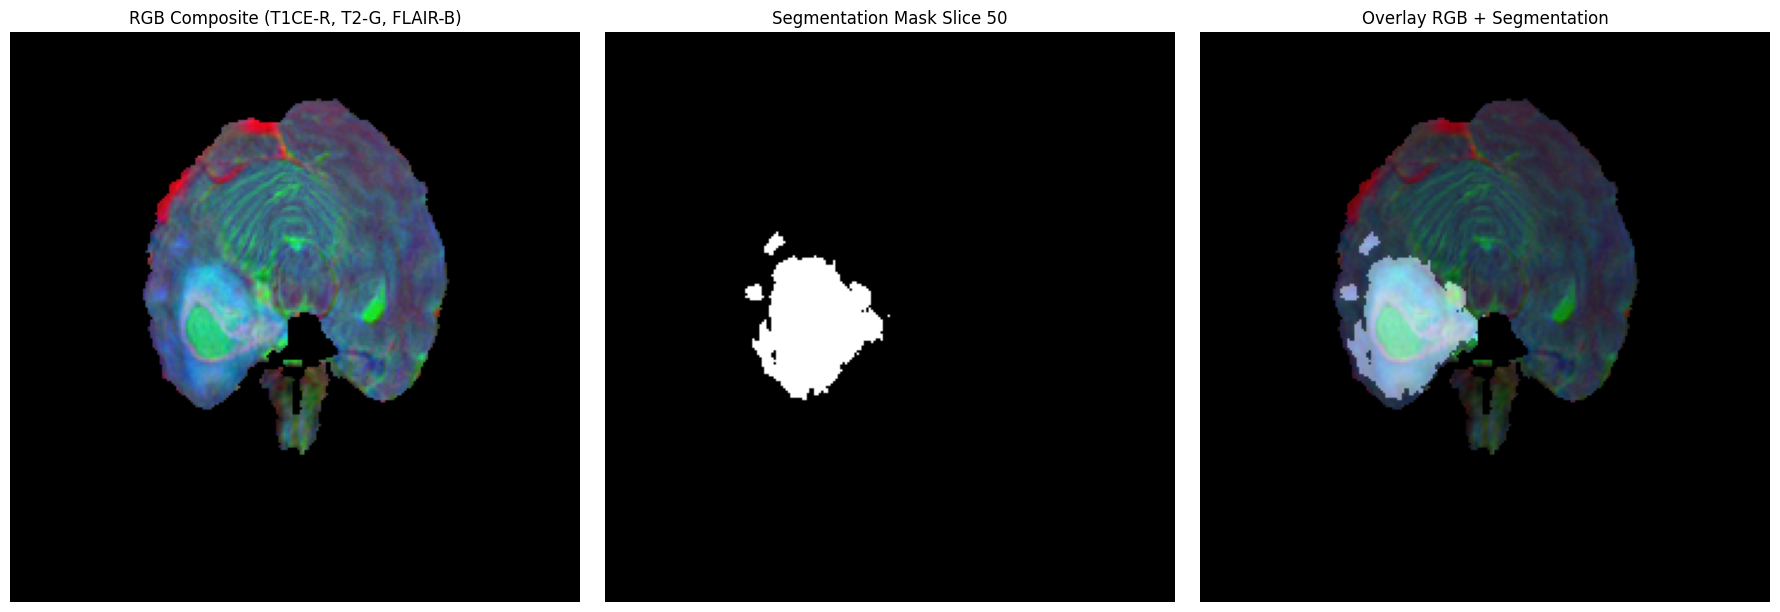

In [116]:
slice_index = 50

path = "../data/raw/brats_nii/training/BraTS20_Training_001/BraTS20_Training_001"
t1ce = nib.load(path + T1CE_SUFFIX).get_fdata()
t2 = nib.load(path + T2_SUFFIX).get_fdata()
flair = nib.load(path + FLAIR_SUFFIX).get_fdata()
seg = nib.load(path + SEG_SUFFIX).get_fdata()

t1ce_slice = t1ce[:, :, slice_index]
t2_slice = t2[:, :, slice_index]
flair_slice = flair[:, :, slice_index]

def normalize(img):
    img_min = np.min(img)
    img_max = np.max(img)
    if img_max - img_min == 0:
        return np.zeros_like(img)
    return (img - img_min) / (img_max - img_min)

t1ce_norm = normalize(t1ce_slice)
t2_norm = normalize(t2_slice)
flair_norm = normalize(flair_slice)

# Stack and convert to torch tensor
rgb_img = torch.from_numpy(np.stack([t1ce_norm, t2_norm, flair_norm], axis=-1)).float()

# Segmentation slice to tensor
seg_slice = torch.from_numpy(seg[:, :, slice_index])
seg_slice = seg_binary = (seg_slice > 0).float()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Use permute to swap axes for RGB image and convert back to numpy for plotting
axes[0].imshow(rgb_img.permute(1, 0, 2).numpy(), origin='lower')
axes[0].set_title('RGB Composite (T1CE-R, T2-G, FLAIR-B)')
axes[0].axis('off')

# Transpose seg slice to match orientation and convert to numpy
axes[1].imshow(seg_slice.T.numpy(), cmap='gray', alpha=1, origin='lower')
axes[1].set_title('Segmentation Mask Slice 50')
axes[1].axis('off')

# Overlay with alpha blending
axes[2].imshow(rgb_img.permute(1, 0, 2).numpy())
axes[2].imshow(seg_slice.T.numpy(), cmap='gray', alpha=0.4, origin='lower')
axes[2].set_title('Overlay RGB + Segmentation')
axes[2].axis('off')

plt.tight_layout()
plt.show()